# Week 05 Day 3 — Exploratory Data Analysis & Visualization

## Matplotlib Foundations

Today I explored data visualization using Matplotlib and Pandas, including histograms, bar charts, scatter plots, line charts, subplots, misleading visualizations, and saving figures.

In [1]:
## Imports + Environment Check
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print(sns.__version__)

Pandas version: 2.3.3
Matplotlib version: 3.10.9
0.13.2


In [2]:
## To save all Figures
import os

os.makedirs("figures", exist_ok=True)

## 1. Setup and Imports

Pandas is used for loading, inspecting, and working with the cleaned datasets.
Matplotlib is used to create and customize visualizations.

This notebook uses the same virtual environment and continues the data analysis work from Day 2.

## Learning Objectives

By the end of this notebook, I will be able to:

- Explain why visualization is an important part of Exploratory Data Analysis (EDA).
- Understand the difference between a Matplotlib Figure and Axes.
- Choose an appropriate plot for a specific data question.
- Create histograms, bar charts, scatter plots, and line charts.
- Create multiple plots using subplots.
- Identify how misleading axis scales can distort interpretation.
- Save a figure as an image for use in a report.
- Write clear findings based on visual evidence.

## 2. Dataset Overview

This notebook continues the data analysis work from Day 2.

Two datasets are used:

1. **Messy Practice Dataset** — a small dataset created for practicing data cleaning and visualization.
2. **Online Retail Dataset** — a real-world sales dataset containing transaction-level information.

The messy dataset is used to reinforce the connection between cleaning and visualization, while the Online Retail dataset is used for the main EDA and visualization analysis.

## 3. Messy Practice Dataset

The first dataset is a small sales dataset created for practicing data cleaning and exploratory data analysis.

It contains four columns:

- `date` — transaction date
- `category` — product category
- `amount` — transaction amount
- `customer_age` — age of the customer

The dataset intentionally contains missing values and inconsistent category capitalization. These issues were addressed during Day 2 cleaning practice.

In [3]:
data = {
    "date": [
        "2026-08-01",
        "2026-08-02",
        None,
        "2026-08-04",
        "2026-08-05",
        "2026-08-06",
        "2026-08-07",
        "2026-08-08"
    ],
    "category": [
        "Electronics",
        "electronics",
        "Furniture",
        None,
        "Clothing",
        "Electronics",
        "furniture",
        "Clothing"
    ],
    "amount": [
        250.0,
        180.0,
        None,
        450.0,
        120.0,
        320.0,
        275.0,
        None
    ],
    "customer_age": [
        25,
        None,
        34,
        41,
        29,
        36,
        None,
        31
    ]
}

df_messy = pd.DataFrame(data)

df_messy

,date,category,amount,customer_age
0,2026-08-01,Electronics,250.0,25.0
1,2026-08-02,electronics,180.0,NaN
2,None,Furniture,NaN,34.0
3,2026-08-04,None,450.0,41.0
4,2026-08-05,Clothing,120.0,29.0
5,2026-08-06,Electronics,320.0,36.0
6,2026-08-07,furniture,275.0,NaN
7,2026-08-08,Clothing,NaN,31.0


### 3.1 Initial Inspection

Before visualization, the dataset is inspected to understand its structure and identify data-quality issues.

The inspection includes the first few rows, data types, summary statistics, and missing-value counts.

In [4]:
df_messy.head()

,date,category,amount,customer_age
0,2026-08-01,Electronics,250.0,25.0
1,2026-08-02,electronics,180.0,NaN
2,None,Furniture,NaN,34.0
3,2026-08-04,None,450.0,41.0
4,2026-08-05,Clothing,120.0,29.0


In [5]:
df_messy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          7 non-null      object 
 1   category      7 non-null      object 
 2   amount        6 non-null      float64
 3   customer_age  6 non-null      float64
dtypes: float64(2), object(2)
memory usage: 384.0+ bytes


In [6]:
df_messy.describe()

,amount,customer_age
count,6.000000,6.000000
mean,265.833333,32.666667
std,114.735202,5.609516
min,120.000000,25.000000
25%,197.500000,29.500000
50%,262.500000,32.500000
75%,308.750000,35.500000
max,450.000000,41.000000


In [7]:
df_messy.isna().sum()

date            1
category        1
amount          2
customer_age    2
dtype: int64

### 3.2 Cleaning Recap

The dataset contains several data-quality issues that were identified during Day 2.

- The `date` column contains a missing value and needs to be converted to datetime.
- The `category` column contains inconsistent capitalization such as `Electronics` and `electronics`.
- The `category` column also contains a missing value.
- The `amount` column contains missing values.
- The `customer_age` column contains missing values.

These issues were handled during the cleaning stage before performing visualization.

In [8]:
df_messy["date"] = pd.to_datetime(df_messy["date"])

df_messy["category"] = df_messy["category"].str.title()

df_messy["category"] = df_messy["category"].fillna("Unknown")

df_messy["amount"] = df_messy["amount"].fillna(df_messy["amount"].median())

df_messy["customer_age"] = df_messy["customer_age"].fillna(
    df_messy["customer_age"].median()
)

df_messy

,date,category,amount,customer_age
0,2026-08-01,Electronics,250.0,25.0
1,2026-08-02,Electronics,180.0,32.5
2,NaT,Furniture,262.5,34.0
3,2026-08-04,Unknown,450.0,41.0
4,2026-08-05,Clothing,120.0,29.0
5,2026-08-06,Electronics,320.0,36.0
6,2026-08-07,Furniture,275.0,32.5
7,2026-08-08,Clothing,262.5,31.0


In [9]:
df_messy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          7 non-null      datetime64[ns]
 1   category      8 non-null      object        
 2   amount        8 non-null      float64       
 3   customer_age  8 non-null      float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 384.0+ bytes


In [10]:
df_messy.isna().sum()

date            1
category        0
amount          0
customer_age    0
dtype: int64

In [11]:
df_messy = df_messy.dropna(subset=["date"])

df_messy.isna().sum()

date            0
category        0
amount          0
customer_age    0
dtype: int64

### Final Cleaning Check

The row with the missing date was removed because the date is important for time-based analysis. Missing numerical values were handled using the median, while inconsistent category capitalization was standardized and the missing category was labeled as `Unknown`.

The resulting DataFrame contains complete values in the columns used for today's visualization tasks.

In [12]:
df_messy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 0 to 7
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          7 non-null      datetime64[ns]
 1   category      7 non-null      object        
 2   amount        7 non-null      float64       
 3   customer_age  7 non-null      float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 280.0+ bytes


## 4. Figure and Axes

Matplotlib uses two important objects:

- **Figure** — the complete canvas or image.
- **Axes** — the actual plotting area inside the Figure.

Using `fig, ax = plt.subplots()` gives explicit control over the plot instead of relying on Matplotlib's hidden current Axes.

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


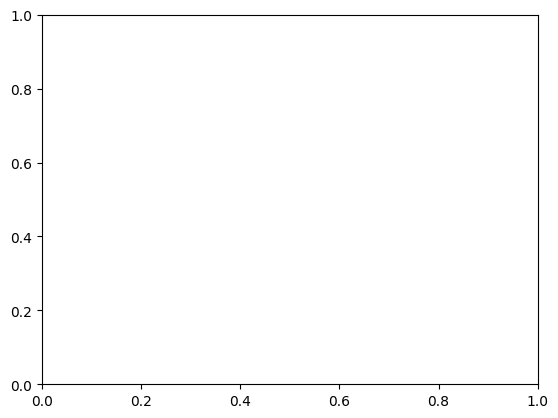

In [13]:
fig, ax = plt.subplots()

print(type(fig))
print(type(ax))


## 5. Histogram — Distribution of Transaction Amount

### Question

What is the distribution of transaction amounts in the cleaned dataset?

A histogram is appropriate because `amount` is a numerical variable and we want to understand how its values are distributed across different ranges.

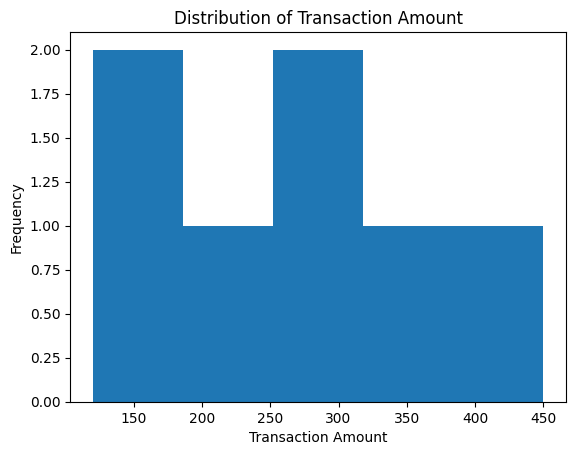

In [14]:
fig, ax = plt.subplots()

ax.hist(df_messy["amount"], bins=5)

ax.set_title("Distribution of Transaction Amount")
ax.set_xlabel("Transaction Amount")
ax.set_ylabel("Frequency")

plt.show()
fig.savefig("figures/amount_histogram.png", dpi=150, bbox_inches="tight")

### Finding

The transaction amounts are spread across a range of approximately 120 to 450. 
The distribution is not concentrated in a single range; instead, the values appear across several different amount intervals. 
With only a small number of observations, the distribution should be interpreted cautiously.

## 6. Bar Chart — Total Amount by Category

### Question

Which product category has the highest total transaction amount?

A bar chart is appropriate because `category` is a categorical variable and we want to compare the total `amount` across different categories.

In [15]:
category_totals = df_messy.groupby("category")["amount"].sum()

category_totals

category
Clothing       382.5
Electronics    750.0
Furniture      275.0
Unknown        450.0
Name: amount, dtype: float64

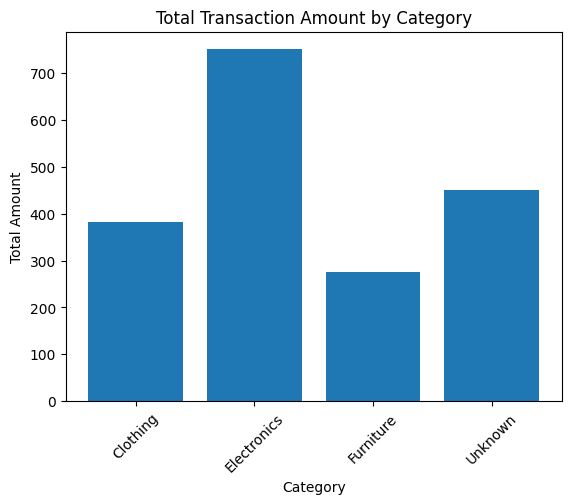

In [16]:
fig, ax = plt.subplots()

ax.bar(category_totals.index, category_totals.values)

ax.set_title("Total Transaction Amount by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Amount")

plt.xticks(rotation=45)
plt.show()
fig.savefig("figures/bar_category_totals.png", dpi=150, bbox_inches="tight")

### Finding

Electronics has the highest total transaction amount at approximately 750, making it the largest contributor among the categories. Furniture has the lowest total amount at approximately 275. Clothing and Unknown fall between these two categories.

## 7. Scatter Plot — Amount vs Customer Age

### Question

Is there a visible relationship between customer age and transaction amount?

A scatter plot is appropriate because both `customer_age` and `amount` are numerical variables. Each point represents one transaction and its corresponding customer age.

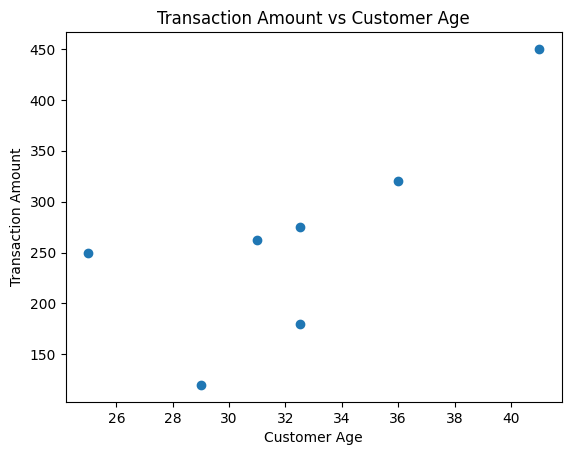

In [17]:
fig, ax = plt.subplots()

ax.scatter(df_messy["customer_age"], df_messy["amount"])

ax.set_title("Transaction Amount vs Customer Age")
ax.set_xlabel("Customer Age")
ax.set_ylabel("Transaction Amount")

plt.show()
fig.savefig("figures/amount_vs_age_scatter.png", dpi=150, bbox_inches="tight")

### Finding

The scatter plot shows a generally positive relationship between customer age and transaction amount. Older customers tend to have higher transaction amounts, although the relationship is not perfectly consistent. Since the dataset contains only a small number of observations, this pattern should be interpreted cautiously.

In [18]:
correlation = df_messy["customer_age"].corr(df_messy["amount"])
correlation

np.float64(0.7473503008298329)

## Correlation Analysis

Correlation measures the strength and direction of the relationship between two variables. In this analysis, we calculated the correlation between customer age and transaction amount.

The correlation value is 0.747, which indicates a relatively strong positive relationship between customer age and transaction amount. This means that as customer age increases, the transaction amount also tends to increase in this dataset.

However, correlation does not imply causation. It only shows that the two variables are associated with each other.

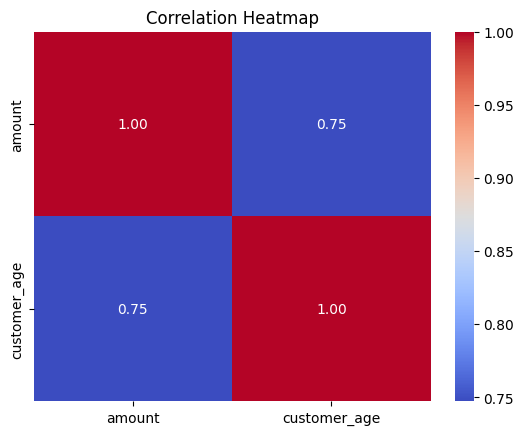

In [19]:
corr = df_messy[["amount", "customer_age"]].corr()

fig, ax = plt.subplots()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=ax
)

ax.set_title("Correlation Heatmap")

fig.savefig(
    "figures/correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Correlation Heatmap Interpretation

The correlation heatmap shows the relationship between customer age and transaction amount.

The correlation value between the two variables is approximately 0.75, indicating a relatively strong positive correlation. This means that older customers tend to have higher transaction amounts in this dataset.

The diagonal values are 1.00 because each variable has a perfect correlation with itself.

Overall, the heatmap confirms the finding from the scatter plot and correlation analysis that customer age and transaction amount have a positive relationship.

## 8. Box Plot — Transaction Amount
Question

What is the distribution of transaction amounts, and are there any potential outliers?

A box plot is appropriate because amount is a numerical variable. It summarizes the distribution using the median, quartiles, and range, and helps identify potential outliers in the transaction amounts.

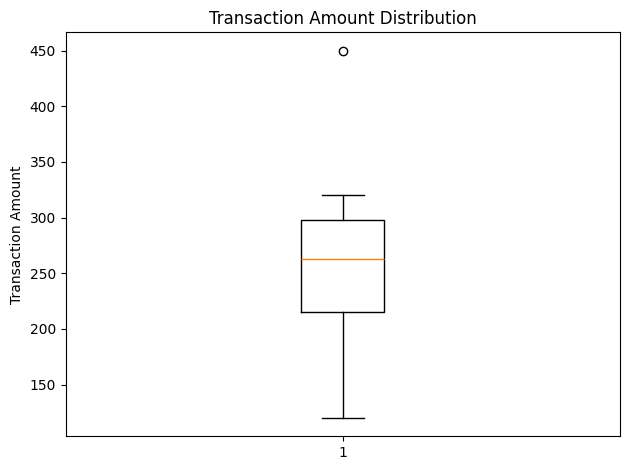

In [20]:
fig, ax = plt.subplots()

ax.boxplot(df_messy["amount"].dropna())

ax.set_title("Transaction Amount Distribution")
ax.set_ylabel("Transaction Amount")

plt.tight_layout()

fig.savefig("figures/amount_boxplot.png", dpi=150, bbox_inches="tight")

plt.show()

## Interpretation of Transaction Amount Distribution
The median transaction amount is around 260, meaning half of all transactions fall below this value and half above it.
The interquartile range (IQR), shown by the box, spans roughly 215 to 295, representing the middle 50% of transactions.
The whiskers extend from about 125 (minimum) to 320 (maximum), covering the typical range of transaction values excluding outliers.
There is a clear outlier around 450, marked as a circle above the upper whisker — this transaction is significantly higher than the rest of the data and falls outside the normal range.
Overall, most transactions are concentrated between 125 and 320, with the distribution appearing slightly right-skewed due to the presence of that high-value outlier.
The outlier at ~450 may warrant further investigation — it could indicate a data entry error, a fraudulent transaction, or simply a legitimate high-value purchase worth flagging separately.

## 9. Subplots — Comparing Multiple Views

Viewing the histogram, bar chart, and scatter plot together makes it easier to understand different aspects of the dataset at the same time. The histogram shows the distribution of transaction amounts, the bar chart compares total amounts across categories, and the scatter plot shows the relationship between customer age and transaction amount. This side-by-side view makes comparison easier than viewing each chart separately.

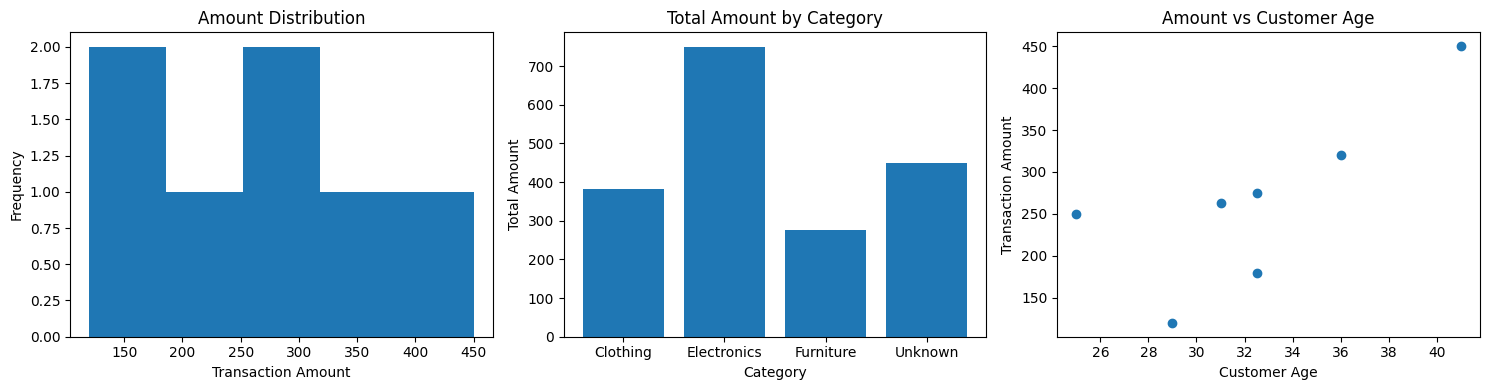

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df_messy["amount"].dropna(), bins=5)
axes[0].set_title("Amount Distribution")
axes[0].set_xlabel("Transaction Amount")
axes[0].set_ylabel("Frequency")

# Bar chart
axes[1].bar(category_totals.index, category_totals.values)
axes[1].set_title("Total Amount by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Total Amount")

# Scatter plot
axes[2].scatter(df_messy["customer_age"], df_messy["amount"])
axes[2].set_title("Amount vs Customer Age")
axes[2].set_xlabel("Customer Age")
axes[2].set_ylabel("Transaction Amount")

plt.tight_layout()
fig.savefig("figures/eda_subplots.png", dpi=150, bbox_inches="tight")
plt.show()

##  Line Chart — Transaction Amount Over Time
Question

Is there a visible trend in transaction amount over time?

A line chart is appropriate because date represents an ordered sequence and amount is a numerical variable. Connecting the observations helps visualize how transaction amounts change over time.

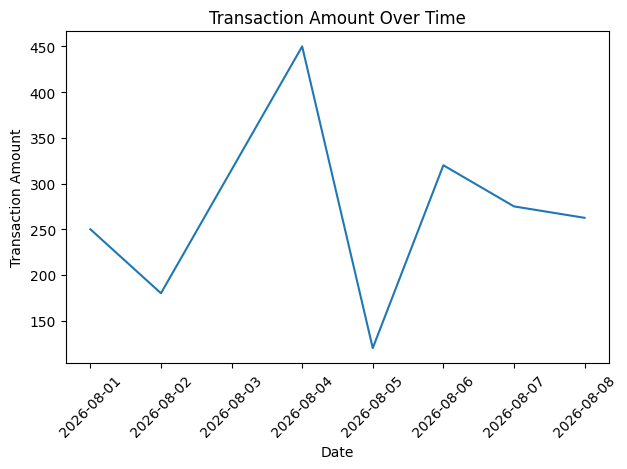

In [22]:
fig, ax = plt.subplots()

ax.plot(df_messy["date"], df_messy["amount"])

ax.set_title("Transaction Amount Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Transaction Amount")

plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig("figures/line_amount_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation of Line Chart
Transaction amounts show a sharp rise from Aug 1 to Aug 4, peaking at ~450 (this matches the outlier seen earlier in the box plot), then a steep drop to a low of ~125 on Aug 5. After that, values climb again to ~320 on Aug 6 before gradually stabilizing around 260–280 through Aug 8, suggesting the market/transactions settled after that mid-week spike-and-dip.

## 10. Misleading Chart — Truncated Axis
Question

How can a truncated y-axis make a chart misleading?

The second bar chart is misleading because the y-axis does not start at zero. Truncating the y-axis exaggerates the visual difference between categories, making relatively small differences in total transaction amounts appear much larger than they actually are.

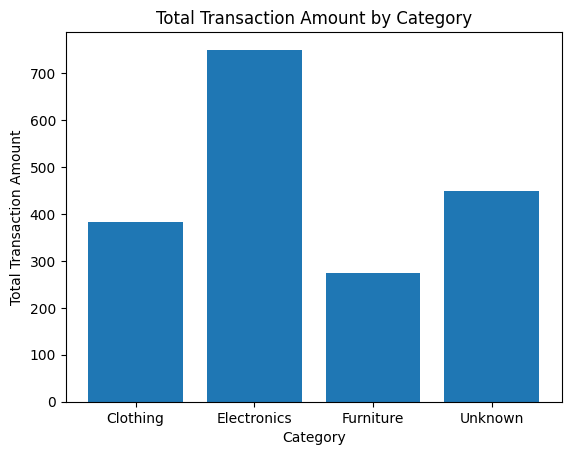

In [23]:
fig, ax = plt.subplots()

ax.bar(category_totals.index, category_totals.values)

ax.set_title("Total Transaction Amount by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Transaction Amount")

plt.show()

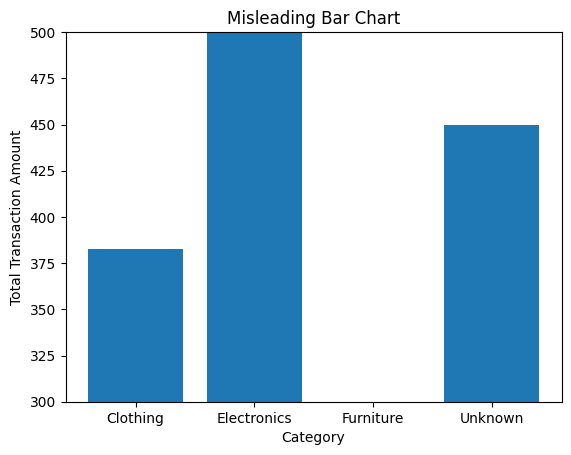

In [24]:
fig, ax = plt.subplots()

ax.bar(category_totals.index, category_totals.values)

ax.set_title("Misleading Bar Chart")
ax.set_xlabel("Category")
ax.set_ylabel("Total Transaction Amount")

ax.set_ylim(300, 500)

plt.show()

## Interpretation
Chart 1 (y-axis from 0) is accurate — Electronics (~730) clearly leads, followed by Unknown (~450), Clothing (~380), and Furniture (~270).

Chart 2 truncates the y-axis (300–500), making Furniture disappear and exaggerating the differences between Clothing, Electronics, and Unknown — this is a classic misleading chart since it distorts the true proportional comparison.

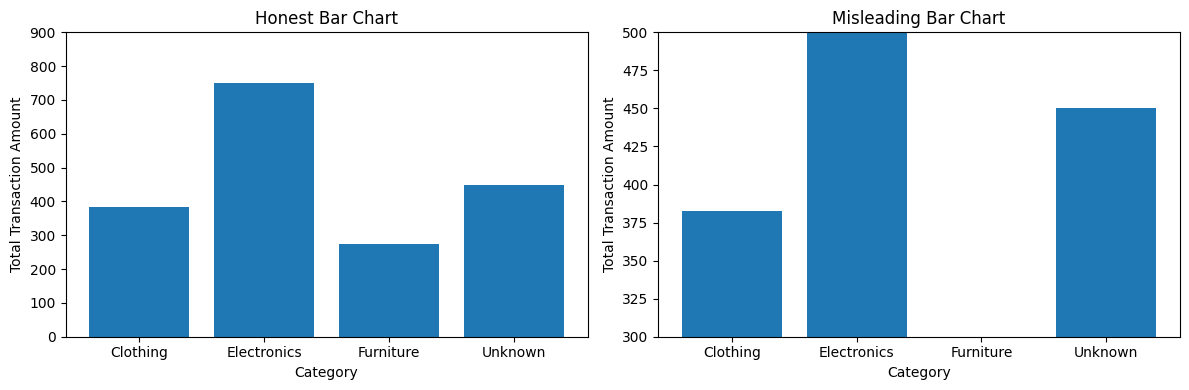

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Honest chart
axes[0].bar(category_totals.index, category_totals.values)
axes[0].set_title("Honest Bar Chart")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Transaction Amount")
axes[0].set_ylim(0, category_totals.max() * 1.2)

# Misleading chart
axes[1].bar(category_totals.index, category_totals.values)
axes[1].set_title("Misleading Bar Chart")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Total Transaction Amount")
axes[1].set_ylim(300, 500)

plt.tight_layout()
fig.savefig("figures/honest_vs_misleading.png", dpi=150, bbox_inches="tight")
plt.show()

## Honest vs Misleading Chart

The honest chart starts the y-axis at zero, which represents the differences between categories fairly. The misleading chart uses a truncated y-axis, making small differences between categories appear much larger. This shows why axis scaling is important for presenting data accurately.

## 11. Technical Summary

### Dataset Overview

The dataset contains transaction-level sales information, including transaction date, product category, transaction amount, and customer age. The data was cleaned by standardizing category names, handling missing numerical values using the median, labeling the missing category as "Unknown", converting the date column to datetime, and removing the row with a missing date.

### Key Findings

1. Electronics has the highest total transaction amount, with approximately 750 in total sales.

2. Customer age and transaction amount show a relatively strong positive correlation of approximately 0.75, indicating that older customers tend to have higher transaction amounts in this dataset.

3. The transaction amount distribution contains a high-value transaction around 450, which appears as a potential outlier in the box plot and creates a noticeable spike in the line chart.

### Limitation

The dataset contains only a small number of observations, so the findings may not generalize to a larger population. In addition, missing numerical values were replaced with median values, which may affect the distribution and correlation results.

## Online Retail Dataset — EDA Overview

This section applies Exploratory Data Analysis (EDA) and visualization techniques to the cleaned Online Retail dataset from Day 2. The dataset contains real-world transaction records including invoice numbers, product codes, product descriptions, quantities, invoice dates, unit prices, customer IDs, and countries. A `TotalSales` column was created by multiplying `Quantity` by `UnitPrice`. The analysis will use appropriate visualizations to understand the distribution of transaction sales, compare sales across countries, examine relationships between numerical variables, identify sales trends over time, detect potential outliers, and compare multiple views of the dataset. Each visualization will be supported by a written interpretation explaining the main finding.

In [27]:
import os

os.makedirs("data", exist_ok=True)

## Load the Online Retail Dataset

The cleaned Online Retail dataset from Day 2 is stored as a CSV file inside the `data` directory. I will load the dataset using Pandas and verify its structure before starting the visualization analysis.

In [28]:
retail_df = pd.read_csv("data/Online_Retail.csv")

retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [29]:
retail_df.shape

(541909, 8)

In [30]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [31]:
retail_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

## Cleaning Recap

The Online Retail dataset was cleaned during Day 2 before performing analysis. The cleaning process included removing duplicate records, converting `InvoiceDate` to datetime format, removing negative quantities and non-positive unit prices for sales analysis, and preserving transactions with missing `CustomerID` because the customer information cannot be reliably reconstructed. The cleaned dataset is now prepared for Exploratory Data Analysis and visualization.

In [32]:
## duplicates remove
retail_df = retail_df.drop_duplicates().copy()

print("Shape after removing duplicates:", retail_df.shape)

Shape after removing duplicates: (536641, 8)


In [33]:
## date convert
retail_df["InvoiceDate"] = pd.to_datetime(retail_df["InvoiceDate"])

print(retail_df["InvoiceDate"].dtype)

datetime64[ns]


In [34]:
## negative quantity remove
retail_df = retail_df[retail_df["Quantity"] >= 0].copy()

print("Negative quantities:", (retail_df["Quantity"] < 0).sum())

Negative quantities: 0


In [35]:
##invalid prices remove

retail_df = retail_df[retail_df["UnitPrice"] > 0].copy()

print("Invalid UnitPrice:", (retail_df["UnitPrice"] <= 0).sum())

Invalid UnitPrice: 0


In [36]:
## Create TotalSales 
retail_df["TotalSales"] = retail_df["Quantity"] * retail_df["UnitPrice"]

retail_df[["Quantity", "UnitPrice", "TotalSales"]].head()

,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [37]:
## Final check
retail_df.info()
retail_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  object        
 8   TotalSales   524878 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 40.0+ MB


InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
TotalSales          0
dtype: int64

In [38]:
## Save Cleaned CSV
retail_df.to_csv("data/Online_Retail_Cleaned.csv", index=False)

In [39]:
## Confirm File created or not
import os

os.listdir("data")

['Online_Retail.csv', 'Online Retail.xlsx', 'Online_Retail_Cleaned.csv']

## Now we Perform Eda on cleaned Dataset
## Histogram — Distribution of Transaction Sales

### Question

What is the distribution of transaction sales in the Online Retail dataset?

A histogram is appropriate because `TotalSales` is a numerical variable. It shows how transaction sales are distributed across different value ranges and helps identify where most transactions are concentrated, whether the distribution is skewed, and whether unusually large transactions are present.

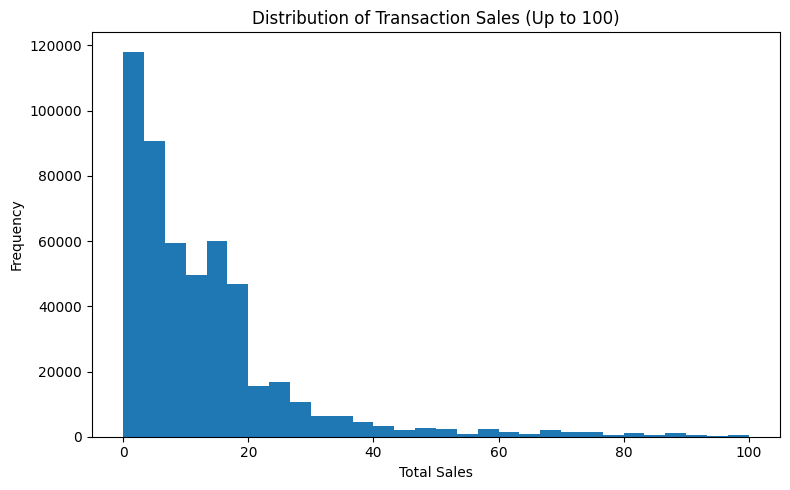

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    retail_df.loc[retail_df["TotalSales"] <= 100, "TotalSales"],
    bins=30
)

ax.set_title("Distribution of Transaction Sales (Up to 100)")
ax.set_xlabel("Total Sales")
ax.set_ylabel("Frequency")

plt.tight_layout()

fig.savefig(
    "figures/retail_total_sales_histogram_zoomed.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Findings — Distribution of Transaction Sales (Up to 100)

- The distribution is **strongly right-skewed**, meaning most transactions have relatively small sales values while a small number have much larger values.
- Most transactions are concentrated between approximately **0 and 20**, with the highest frequency occurring in the lower sales range.
- The frequency decreases sharply as transaction sales increase, and values above approximately **40** occur much less frequently.
- The distribution has a **long right tail**, indicating the presence of a small number of unusually large transactions.
- The median transaction sales value is approximately **9.92**, while the mean is approximately **20.28**. The higher mean is influenced by the extreme high-value transactions.
- The maximum transaction value is approximately **168,469.60**, which is much larger than the typical transaction value.
- These extreme values may represent legitimate bulk purchases or special transactions and could be investigated separately during further analysis.

## Bar Chart — Total Sales by Country

### Question

Which countries generate the highest total sales in the Online Retail dataset?

A bar chart is appropriate because `Country` is a categorical variable and `TotalSales` is a numerical variable. It allows us to compare the total sales generated by different countries and identify the countries with the highest sales.

In [44]:
country_sales = (
    retail_df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalSales, dtype: float64

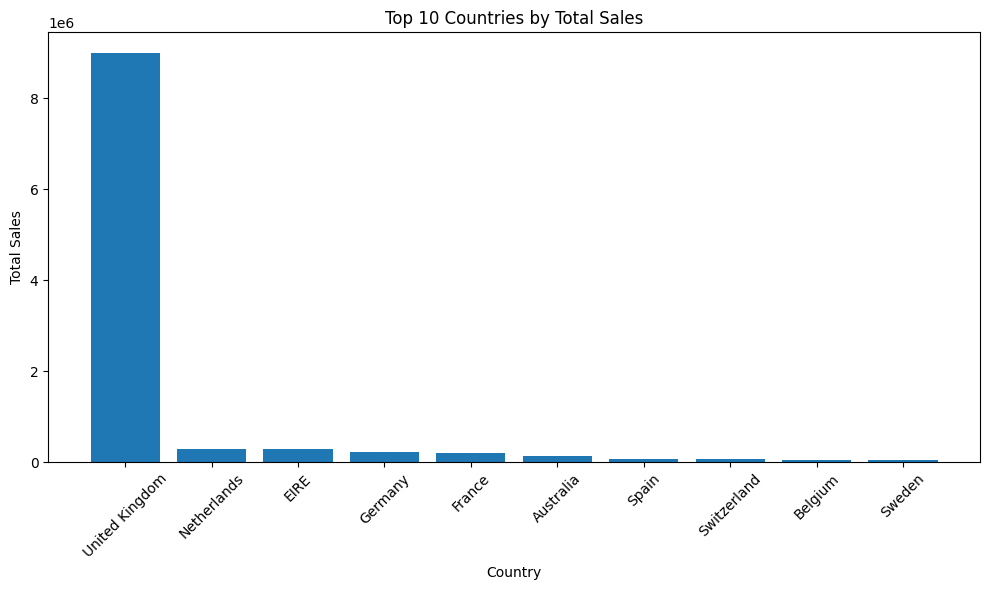

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

top_countries = country_sales.head(10)

ax.bar(top_countries.index, top_countries.values)

ax.set_title("Top 10 Countries by Total Sales")
ax.set_xlabel("Country")
ax.set_ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    "figures/top_10_countries_sales.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Findings — Top 10 Countries by Total Sales

The United Kingdom has by far the highest total sales, significantly outperforming all other countries in the dataset. The Netherlands and EIRE follow as the next highest contributors, while Germany, France, Australia, Spain, Switzerland, Belgium, and Sweden have considerably lower sales.

Overall, the results show that sales are highly concentrated in the UK market. This suggests that the business relies heavily on its primary market, while other countries contribute a much smaller share of total sales. Expanding into lower-performing international markets could provide opportunities for greater revenue diversification.

## Scatter Plot — Quantity vs Unit Price

### Question

Is there a visible relationship between the quantity of items purchased and their unit price?

A scatter plot is appropriate because both `Quantity` and `UnitPrice` are numerical variables. Each point represents a transaction and shows the relationship between the number of items purchased and their unit price.

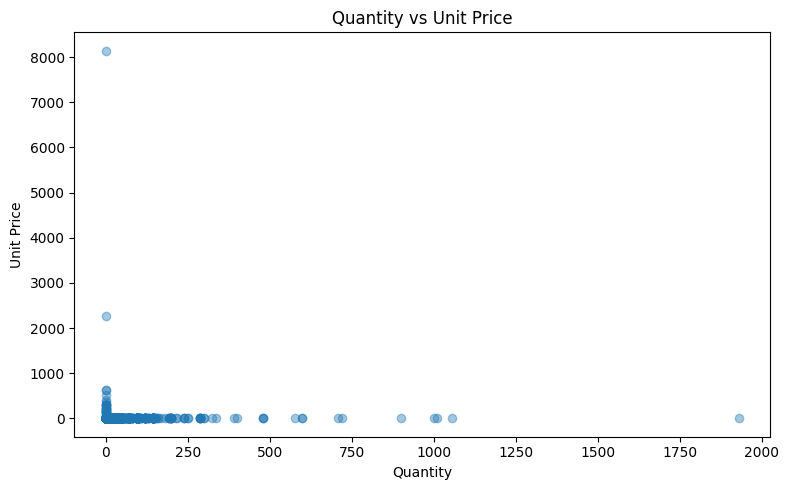

In [46]:
sample_df = retail_df.sample(10000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    sample_df["Quantity"],
    sample_df["UnitPrice"],
    alpha=0.4
)

ax.set_title("Quantity vs Unit Price")
ax.set_xlabel("Quantity")
ax.set_ylabel("Unit Price")

plt.tight_layout()

fig.savefig(
    "figures/quantity_vs_unitprice_scatter.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Findings — Quantity vs Unit Price

The scatter plot shows that most transactions are concentrated near the lower values of both quantity and unit price, indicating that typical purchases involve relatively small quantities and low-priced items.

There is **no clear linear relationship** between quantity and unit price; higher quantities do not consistently correspond to higher or lower prices.

A small number of extreme observations appear on both axes, including transactions with unusually high unit prices and very large quantities. These outliers may represent bulk purchases, high-value products, or unusual records and can strongly affect statistical analyses such as correlation or regression.

Overall, the typical transactions are concentrated near the lower range, while the extreme values require separate investigation in further analysis.

## Line Chart — Total Sales Over Time

### Question

How do total sales change over time?

A line chart is appropriate because `InvoiceDate` represents an ordered time sequence and `TotalSales` is a numerical variable. It helps identify overall trends, peaks, drops, and changes in sales activity over time.

In [47]:
daily_sales = (
    retail_df.groupby(retail_df["InvoiceDate"].dt.date)["TotalSales"]
    .sum()
)

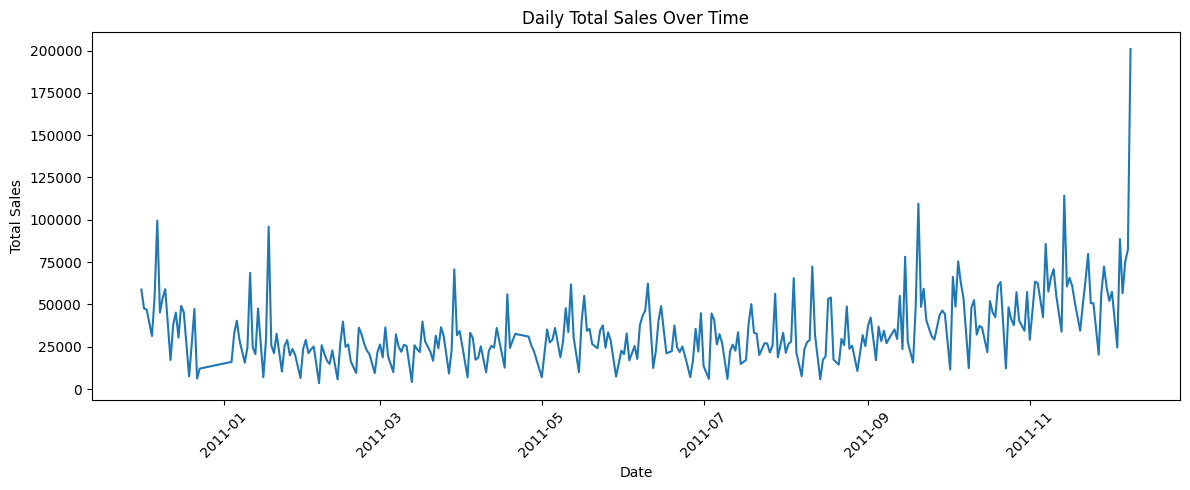

In [48]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(daily_sales.index, daily_sales.values)

ax.set_title("Daily Total Sales Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    "figures/daily_total_sales.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Findings — Daily Total Sales Over Time

The line chart shows considerable day-to-day variation in total sales, with most daily sales fluctuating between approximately 10,000 and 75,000.

Sales activity appears to increase toward the later part of the year, particularly from September and October onwards. Several significant spikes can be observed throughout the period, including peaks around January, September, and November.

The largest spike occurs near December 2011, reaching approximately 200,000, making it a notable outlier compared with typical daily sales.

The repeated fluctuations may reflect changes in daily purchasing activity, while the stronger sales toward the end of the year may indicate seasonal retail demand. However, further analysis would be needed to confirm the exact causes of these patterns.

## Top 10 Customers by Total Sales

### Question

Which customers generated the highest total sales?

A bar chart is appropriate because we want to compare total sales across individual customers. Transactions with missing `CustomerID` are excluded because a valid customer identifier is required for customer-level analysis.

In [50]:
customer_sales = (
    retail_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_sales

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalSales, dtype: float64

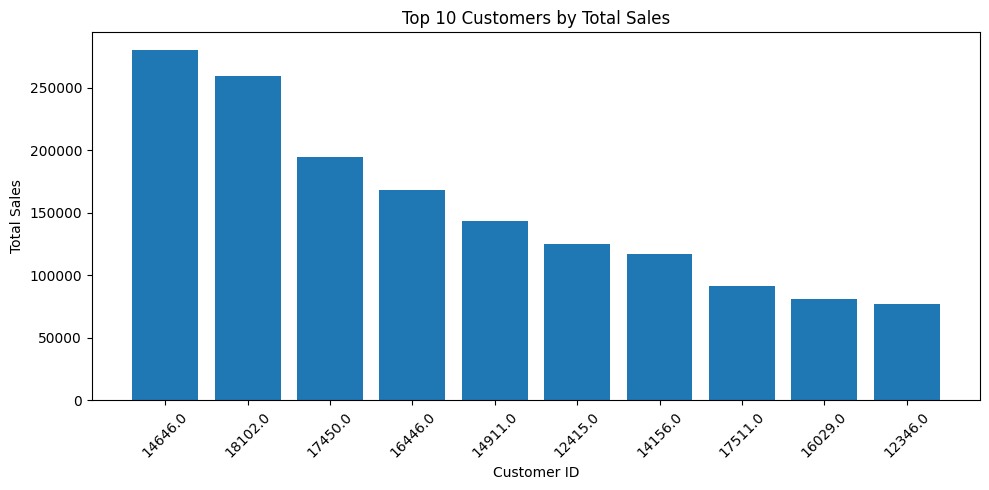

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(customer_sales.index.astype(str), customer_sales.values)

ax.set_title("Top 10 Customers by Total Sales")
ax.set_xlabel("Customer ID")
ax.set_ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    "figures/top_10_customers_sales.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Findings — Top 10 Customers by Total Sales

Customer 14646 has the highest total sales at approximately 280,000, followed by Customer 18102 with around 260,000. Sales then gradually decrease across the remaining top customers, with Customers 17450 and 16446 also showing relatively high sales.

The top two customers generate noticeably more sales than most of the other customers in the top 10, indicating that some customers contribute substantially more revenue than others.

These high-value customers may be important for customer retention and loyalty strategies. However, the chart alone does not establish a Pareto (80/20) pattern, so that would require a separate analysis of the full customer base.

## Top 10 Products by Total Sales

### Question

Which products generated the highest total sales?

A bar chart is appropriate because we want to compare total sales across different products. The analysis groups transactions by `Description` and calculates the total `TotalSales` for each product.

In [52]:
top_products = (
    retail_df.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: TotalSales, dtype: float64

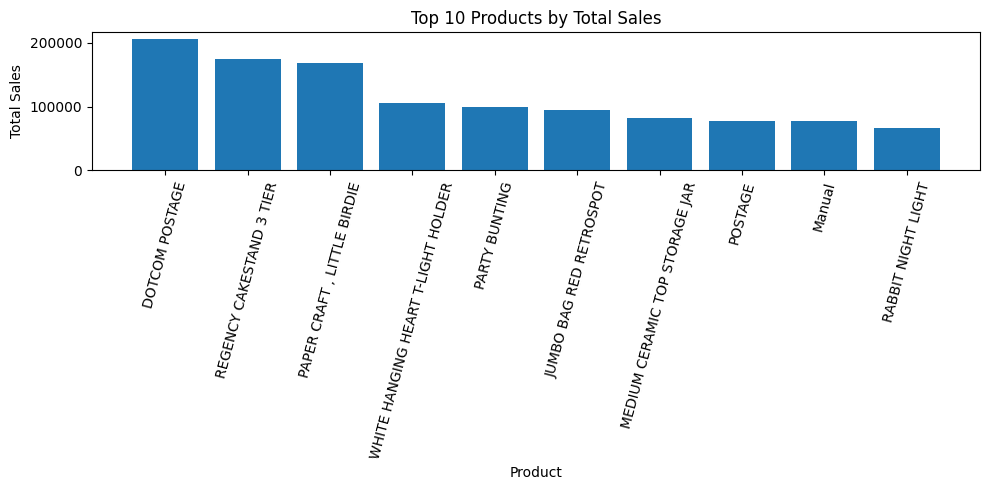

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(top_products.index, top_products.values)

ax.set_title("Top 10 Products by Total Sales")
ax.set_xlabel("Product")
ax.set_ylabel("Total Sales")

plt.xticks(rotation=75)
plt.tight_layout()

fig.savefig(
    "figures/top_10_products_sales.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Findings — Top 10 Products by Total Sales

The top-selling product is **"DOTCOM POSTAGE"**, generating approximately 200,000 in total sales and clearly exceeding the other products in the ranking.

**"REGENCY CAKESTAND 3 TIER"** and **"PAPER CRAFT, LITTLE BIRDIE"** follow with approximately 150,000–160,000 in total sales. The remaining products show a gradual decline and are mostly concentrated between approximately 80,000 and 100,000.

Some entries, such as **"POSTAGE"** and **"Manual"**, do not represent typical merchandise and may correspond to shipping or administrative transactions. These entries should be considered separately when identifying the best-selling physical products.

Overall, the results show that sales are concentrated among a relatively small number of entries. Further analysis should distinguish actual products from non-product transactions to obtain a more accurate picture of merchandise performance.

## Subplots — Multiple EDA Views

Viewing multiple visualizations together provides a broader understanding of the dataset.

The histogram shows the distribution of transaction sales, the bar chart compares sales across countries, and the scatter plot examines the relationship between quantity and unit price. Combining these views makes it easier to compare different aspects of the dataset without switching between separate charts.

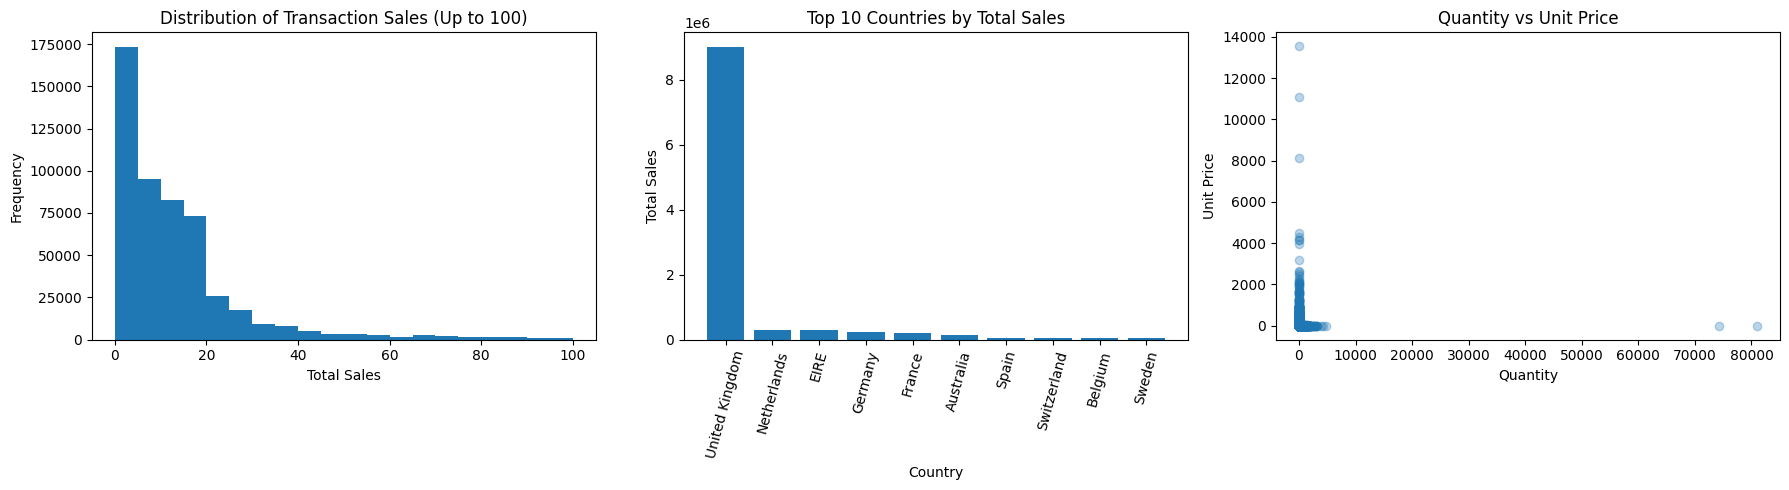

In [56]:
top_countries = (
    retail_df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram — focus on typical transaction sales
axes[0].hist(
    retail_df.loc[retail_df["TotalSales"] <= 100, "TotalSales"],
    bins=20
)

axes[0].set_title("Distribution of Transaction Sales (Up to 100)")
axes[0].set_xlabel("Total Sales")
axes[0].set_ylabel("Frequency")


# Top 10 Countries
axes[1].bar(
    top_countries.index,
    top_countries.values
)

axes[1].set_title("Top 10 Countries by Total Sales")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Total Sales")

axes[1].tick_params(axis="x", rotation=75)


# Scatter Plot
axes[2].scatter(
    retail_df["Quantity"],
    retail_df["UnitPrice"],
    alpha=0.3
)

axes[2].set_title("Quantity vs Unit Price")
axes[2].set_xlabel("Quantity")
axes[2].set_ylabel("Unit Price")


plt.tight_layout()

fig.savefig(
    "figures/eda_subplots_retail.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Misleading Visualization — Truncated Axis

### Question

How can a truncated axis make a chart misleading?

A chart can exaggerate differences when the y-axis does not start at zero. To understand this effect, I will create an honest chart and a deliberately misleading chart using the same sales data.

The purpose is to show how axis scaling can change the visual interpretation of the same underlying data.

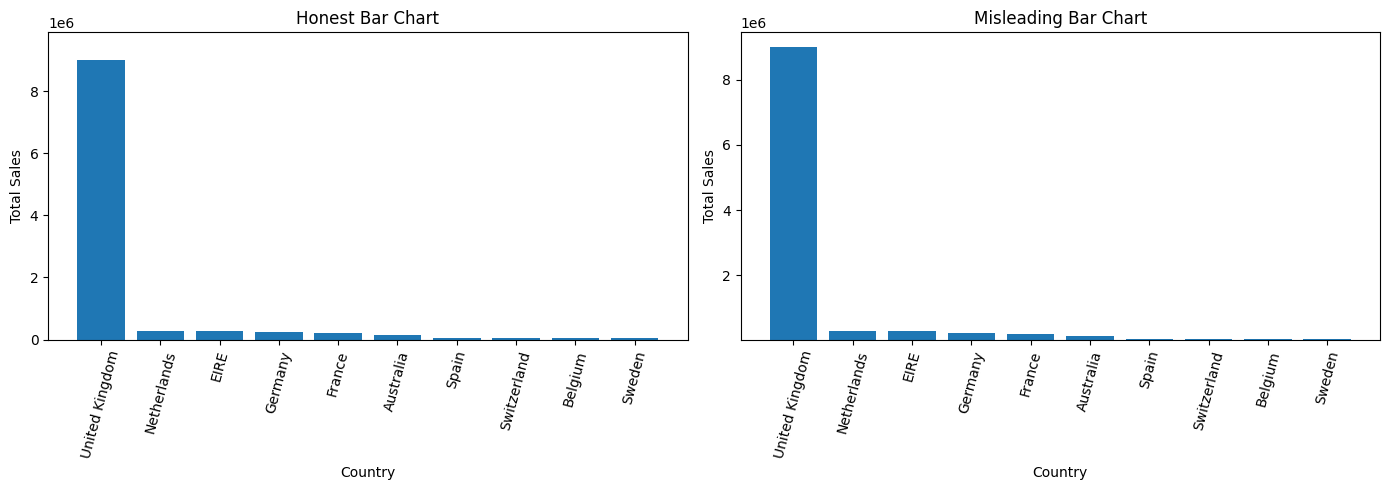

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Honest chart
axes[0].bar(
    top_countries.index,
    top_countries.values
)

axes[0].set_title("Honest Bar Chart")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Total Sales")
axes[0].set_ylim(0, top_countries.max() * 1.1)

axes[0].tick_params(axis="x", rotation=75)


# Misleading chart
axes[1].bar(
    top_countries.index,
    top_countries.values
)

axes[1].set_title("Misleading Bar Chart")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Total Sales")

# Truncated y-axis
axes[1].set_ylim(
    top_countries.min() * 0.8,
    top_countries.max() * 1.05
)

axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()

fig.savefig(
    "figures/honest_vs_misleading_retail.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Findings
Both the "Honest" and "Misleading" bar charts appear visually similar in this case, since the extreme scale of UK sales (~9 million) compared to other countries (<1 million) makes minor axis manipulations difficult to perceive. This highlights that misleading visualizations aren't always obvious — the underlying data's scale itself can mask deceptive techniques like axis truncation. This reinforces the importance of always checking a chart's axis range and scale explicitly, rather than relying on visual comparison alone.

# Technical Summary

## Dataset Overview

The Online Retail dataset contains transaction-level sales records, including invoice numbers, products, quantities, transaction dates, unit prices, customer IDs, and countries.

The original dataset contained 541,909 records. During cleaning, duplicate records, negative-quantity transactions, and non-positive unit prices were removed. The `InvoiceDate` column was converted to datetime format, and a `TotalSales` column was created using `Quantity × UnitPrice`.

Missing `CustomerID` values were not artificially filled because the actual customer information could not be reliably reconstructed. These transactions were retained for general sales analysis but excluded when customer-level analysis was required.

## Key Findings

The distribution of transaction sales is strongly right-skewed. Most transactions have relatively small sales values, while a small number of high-value transactions create a long right tail.

Sales are heavily concentrated in the United Kingdom, which generates substantially higher total sales than the other countries in the dataset.

The scatter plot of Quantity versus Unit Price shows no clear linear relationship. Most transactions are concentrated around lower quantities and prices, with a small number of extreme observations.

Daily sales also show considerable variation over time, including several prominent spikes and stronger sales activity toward the later part of the year.

The customer and product analyses also show that sales are concentrated among a relatively small number of customers and product entries.

## Limitation

A major limitation is the large number of transactions with missing `CustomerID` values. This prevents complete customer-level analysis because some transactions cannot be linked to a known customer.

Another limitation is that the dataset contains sales revenue but does not provide product cost or profit information. Therefore, high sales revenue should not be interpreted as high profitability.